# 🔮 Notebook 02: Modelagem Preditiva — Holt-Winters, LSTM e Gradient Boosting
**Disciplina**: Técnicas de IA Aplicadas a Sistemas de Energia
**Programa**: Mestrado Profissional — IFSC
**Autor**: Dilsonei José Rigotti

---

## 🎯 Objetivo
Comparar três modelos preditivos de séries temporais — **Holt-Winters**, **LSTM (TensorFlow/Keras)**
e **Gradient Boosting** (HistGradientBoostingRegressor) — para o consumo mensal do Subgrupo B3
Comercial Cativo (CELESC), conforme a Seção V do relatório final.

> **Nota de versão:** este notebook substitui a versão anterior (`02_modelos_preditivos_sarimax_lstm.ipynb`),
> que comparava SARIMAX vs. Gradient Boosting. O SARIMAX foi removido da análise; a comparação de
> modelos do trabalho passou a ser Holt-Winters vs. LSTM (Seção V.A–V.B, avaliação em janela única de
> teste — Tabela I) e Holt-Winters vs. Gradient Boosting vs. LSTM (Seção V.C, validação walk-forward
> de 21 janelas — Tabela IV), que é a evidência usada para apontar o modelo mais robusto.

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import shapiro, wilcoxon

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs("../results/plots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
print("Imports OK")

Imports OK


## 1. Carregamento da Série Temporal

Consumo mensal do Subgrupo B3 Comercial Cativo, saneado pelo Notebook 0.
Aceita tanto o arquivo consolidado do Notebook 0 (`b3_cativo_mensal.csv`) quanto o arquivo legado
(`Subgrupo_B3_Comercial_Tratado_1994_2026_B3_Cativo.csv`), para compatibilidade.

In [2]:
def carregar_serie_b3_cativo():
    caminho_novo = "../data/processed/b3_cativo_mensal.csv"
    caminho_legado = "../data/processed/Subgrupo_B3_Comercial_Tratado_1994_2026_B3_Cativo.csv"

    if os.path.exists(caminho_novo):
        df = pd.read_csv(caminho_novo)
    else:
        df = pd.read_csv(caminho_legado, sep=";", decimal=",", encoding="utf-8-sig")

    df["data"] = pd.to_datetime({"year": df["ano"], "month": df["mes"], "day": 1})
    df = df.sort_values("data").reset_index(drop=True)
    df_ts = df.set_index("data")
    ts = df_ts["consumo_mwh"].asfreq("MS").interpolate(method="linear")
    return ts


ts = carregar_serie_b3_cativo()
print(f"Série carregada: {len(ts)} meses ({ts.index[0].strftime('%Y-%m')} a {ts.index[-1].strftime('%Y-%m')})")
ts.tail()

Série carregada: 376 meses (1994-12 a 2026-03)


data
2025-11-01    221806.494385
2025-12-01    230805.837001
2026-01-01    270675.630533
2026-02-01    274307.306010
2026-03-01    298529.444757
Freq: MS, Name: consumo_mwh, dtype: float64

## 2. Funções de Modelagem

Funções reutilizadas tanto na comparação de janela única (Seção 3) quanto na validação
walk-forward (Seção 4), garantindo que os dois experimentos usem exatamente a mesma lógica de
ajuste e previsão para cada modelo.

In [3]:
N_LAGS = 12          # defasagens usadas pelo Gradient Boosting
JANELA_LSTM = 12      # janela deslizante (lookback) do LSTM


def calc_metrics(y_true, y_pred, nome_modelo):
    comum = y_true.index.intersection(y_pred.index)
    yt, yp = y_true.loc[comum], y_pred.loc[comum]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100
    return {"Modelo": nome_modelo, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "MAPE (%)": round(mape, 2)}


def fit_forecast_hw(serie_treino, n_passos):
    '''Holt-Winters com tendência e sazonalidade aditivas (12 períodos).'''
    modelo = ExponentialSmoothing(serie_treino, trend="add", seasonal="add", seasonal_periods=12)
    resultado = modelo.fit()
    return resultado.forecast(n_passos)


def criar_lags(serie, n_lags=N_LAGS):
    df = pd.DataFrame(index=serie.index)
    df["y"] = serie.values
    df["mes"] = df.index.month
    df["ano"] = df.index.year
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)
    return df.dropna()


def fit_forecast_gb(serie_treino, n_passos, n_lags=N_LAGS):
    '''Gradient Boosting (HistGradientBoostingRegressor) com defasagens 1-12 e previsão recursiva.'''
    df_feat = criar_lags(serie_treino, n_lags)
    X_train, y_train = df_feat.drop(columns=["y"]), df_feat["y"]

    modelo = HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)

    historico = serie_treino.copy()
    datas_futuras = pd.date_range(serie_treino.index[-1] + pd.offsets.MonthBegin(1), periods=n_passos, freq="MS")
    previsoes = []
    for data in datas_futuras:
        linha = {"mes": data.month, "ano": data.year}
        for lag in range(1, n_lags + 1):
            linha[f"lag_{lag}"] = historico.iloc[-lag]
        x_linha = pd.DataFrame([linha])[X_train.columns]
        y_hat = modelo.predict(x_linha)[0]
        previsoes.append(y_hat)
        historico.loc[data] = y_hat

    return pd.Series(previsoes, index=datas_futuras)


def criar_janelas(valores, janela=JANELA_LSTM):
    X, y = [], []
    for i in range(janela, len(valores)):
        X.append(valores[i - janela:i])
        y.append(valores[i])
    return np.array(X), np.array(y)


def fit_forecast_lstm(serie_treino, serie_validacao, n_passos, janela=JANELA_LSTM, epochs=100, verbose=0):
    '''LSTM (32 unidades) + Dense(16, ReLU) + saída linear.
    Normalização z-score ajustada apenas no treino (sem vazamento de dados).
    Early stopping monitorando a perda de validação, quando há série de validação.
    Previsão recursiva (multi-passo) sobre n_passos meses à frente.
    '''
    media, desvio = serie_treino.mean(), serie_treino.std()
    treino_norm = (serie_treino - media) / desvio

    tem_validacao = serie_validacao is not None and len(serie_validacao) > 0
    if tem_validacao:
        val_norm = (serie_validacao - media) / desvio
        serie_val_completa = pd.concat([treino_norm.iloc[-janela:], val_norm])
        X_val, y_val = criar_janelas(serie_val_completa.values, janela)
        X_val = X_val.reshape((-1, janela, 1))
        dados_validacao = (X_val, y_val)
    else:
        val_norm = pd.Series(dtype=float)
        dados_validacao = None

    X_train, y_train = criar_janelas(treino_norm.values, janela)
    X_train = X_train.reshape((-1, janela, 1))

    tf.random.set_seed(RANDOM_STATE)
    modelo = keras.Sequential([
        keras.layers.Input(shape=(janela, 1)),
        keras.layers.LSTM(32),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss="mse")

    callbacks = []
    if dados_validacao is not None:
        callbacks.append(keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True))

    modelo.fit(
        X_train, y_train,
        validation_data=dados_validacao,
        epochs=epochs, batch_size=16,
        callbacks=callbacks, verbose=verbose,
    )

    historico_norm = list(treino_norm.values) + list(val_norm.values)
    janela_atual = historico_norm[-janela:]
    previsoes_norm = []
    for _ in range(n_passos):
        x_in = np.array(janela_atual[-janela:]).reshape((1, janela, 1))
        y_hat = float(modelo.predict(x_in, verbose=0)[0, 0])
        previsoes_norm.append(y_hat)
        janela_atual.append(y_hat)

    ultima_data = serie_validacao.index[-1] if tem_validacao else serie_treino.index[-1]
    datas_futuras = pd.date_range(ultima_data + pd.offsets.MonthBegin(1), periods=n_passos, freq="MS")
    previsoes = np.array(previsoes_norm) * desvio + media
    return pd.Series(previsoes, index=datas_futuras), modelo


print("Funções de modelagem definidas: Holt-Winters, Gradient Boosting, LSTM.")

Funções de modelagem definidas: Holt-Winters, Gradient Boosting, LSTM.


## 3. Comparação em Janela Única de Teste (Tabela I do relatório)

Split cronológico usado no relatório (Seção V):
- **Treino**: dez/1994 – mar/2022 (328 meses)
- **Validação**: abr/2022 – mar/2024 (24 meses)
- **Teste**: abr/2024 – mar/2026 (24 meses)

O Holt-Winters não usa a validação para ajuste de hiperparâmetros (não há early stopping),
por isso é ajustado sobre treino + validação (352 meses, até mar/2024) antes de prever o teste.
O LSTM usa a validação para early stopping, conforme a Seção V.B do relatório.

Esta seção reproduz exatamente a Tabela I do relatório (Holt-Winters x LSTM). O Gradient Boosting
não participa desta comparação de janela única — ele é incorporado apenas na validação
walk-forward da Seção 4 (Tabela IV), como explicado na Seção V.C do relatório.

In [4]:
TREINO_FIM = "2022-03-01"
VALIDACAO_INICIO, VALIDACAO_FIM = "2022-04-01", "2024-03-01"
TESTE_INICIO, TESTE_FIM = "2024-04-01", "2026-03-01"

treino = ts[ts.index <= TREINO_FIM]
validacao = ts[(ts.index >= VALIDACAO_INICIO) & (ts.index <= VALIDACAO_FIM)]
teste = ts[(ts.index >= TESTE_INICIO) & (ts.index <= TESTE_FIM)]

print(f"Treino:    {len(treino)} meses ({treino.index[0]:%Y-%m} a {treino.index[-1]:%Y-%m})")
print(f"Validação: {len(validacao)} meses ({validacao.index[0]:%Y-%m} a {validacao.index[-1]:%Y-%m})")
print(f"Teste:     {len(teste)} meses ({teste.index[0]:%Y-%m} a {teste.index[-1]:%Y-%m})")

Treino:    328 meses (1994-12 a 2022-03)
Validação: 24 meses (2022-04 a 2024-03)
Teste:     24 meses (2024-04 a 2026-03)


In [5]:
# Holt-Winters: ajustado sobre treino + validação (352 meses)
treino_mais_val = pd.concat([treino, validacao])
pred_hw = fit_forecast_hw(treino_mais_val, len(teste))

# LSTM: treino (328) + validação (24) para early stopping, previsão recursiva sobre o teste (24)
pred_lstm, modelo_lstm = fit_forecast_lstm(treino, validacao, len(teste))

metrics_hw = calc_metrics(teste, pred_hw, "Holt-Winters")
metrics_lstm = calc_metrics(teste, pred_lstm, "LSTM")

tabela1 = pd.DataFrame([metrics_hw, metrics_lstm])
with open("../data/processed/tabela1_hw_lstm_janela_unica.json", "w", encoding="utf-8") as f:
    json.dump([metrics_hw, metrics_lstm], f, ensure_ascii=False, indent=2)

print("TABELA I — Comparação de Desempenho dos Modelos (período de teste, abr/2024–mar/2026)")
print(tabela1.to_string(index=False))

TABELA I — Comparação de Desempenho dos Modelos (período de teste, abr/2024–mar/2026)
      Modelo     RMSE      MAE  MAPE (%)
Holt-Winters 45525.87 39942.97     16.48
        LSTM 32220.84 27240.05     11.45


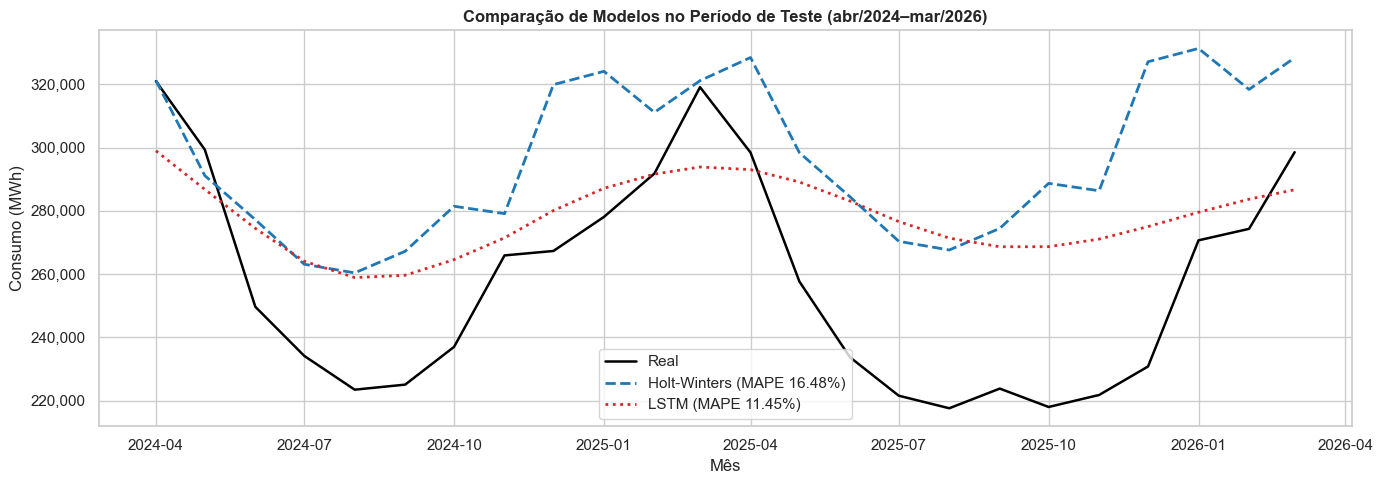

Figura salva: results/plots/02_comparativo_hw_lstm_teste.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(teste.index, teste.values, label="Real", color="black", linewidth=1.8)
ax.plot(pred_hw.index, pred_hw.values,
        label=f"Holt-Winters (MAPE {metrics_hw['MAPE (%)']:.2f}%)",
        color="#1f77b4", linestyle="--", linewidth=2)
ax.plot(pred_lstm.index, pred_lstm.values,
        label=f"LSTM (MAPE {metrics_lstm['MAPE (%)']:.2f}%)",
        color="#d62728", linestyle=":", linewidth=2)

ax.set_title("Comparação de Modelos no Período de Teste (abr/2024–mar/2026)", fontsize=12, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Consumo (MWh)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../results/plots/02_comparativo_hw_lstm_teste.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/02_comparativo_hw_lstm_teste.png")

## 4. Validação Walk-Forward (21 janelas, 2005–2025) — Incorporando o Gradient Boosting (Tabela IV)

A comparação da Tabela I usa uma única janela de teste, sensível ao regime específico desse
período (o "declínio de 2025"). Para avaliar qual modelo generaliza melhor ao longo do histórico,
21 janelas de 12 meses (uma por ano-calendário, 2005–2025) são usadas: em cada janela, os três
modelos são **retreinados do zero** com todo o histórico disponível até o fim do ano anterior
(janela expansiva), e avaliados sobre os 12 meses daquele ano.

O Gradient Boosting é incorporado especificamente nesta validação — por isso ele não aparece na
Tabela I. Apenas o MAPE (métrica percentual) é usado, pois RMSE/MAE absolutos não são comparáveis
entre janelas com bases de consumo tão diferentes (o B3 cresceu de ~100 mil para mais de 300 mil
MWh/mês entre as janelas mais antigas e as mais recentes).

In [7]:
ANOS_TESTE = list(range(2005, 2026))  # 21 janelas
MESES_VALIDACAO_LSTM = 24              # últimos N meses do treino usados como validação (early stopping)

registros = []

for ano_teste in ANOS_TESTE:
    treino_wf = ts[ts.index < f"{ano_teste}-01-01"]
    teste_wf = ts[(ts.index >= f"{ano_teste}-01-01") & (ts.index < f"{ano_teste + 1}-01-01")]
    if len(teste_wf) < 12 or len(treino_wf) < (MESES_VALIDACAO_LSTM + JANELA_LSTM + 12):
        print(f"Janela {ano_teste}: histórico insuficiente, pulando.")
        continue

    # Holt-Winters e Gradient Boosting: ajustados sobre todo o histórico disponível (treino_wf)
    pred_hw_wf = fit_forecast_hw(treino_wf, len(teste_wf))
    pred_gb_wf = fit_forecast_gb(treino_wf, len(teste_wf))

    # LSTM: últimos MESES_VALIDACAO_LSTM meses do histórico como validação (early stopping)
    sub_treino = treino_wf.iloc[:-MESES_VALIDACAO_LSTM]
    sub_val = treino_wf.iloc[-MESES_VALIDACAO_LSTM:]
    pred_lstm_wf, _ = fit_forecast_lstm(sub_treino, sub_val, len(teste_wf), epochs=60)

    for nome, previsao in [("Holt-Winters", pred_hw_wf), ("Gradient Boosting", pred_gb_wf), ("LSTM", pred_lstm_wf)]:
        m = calc_metrics(teste_wf, previsao, nome)
        registros.append({"ano_teste": ano_teste, "modelo": nome, "mape": m["MAPE (%)"]})

    print(f"Janela {ano_teste}: concluída ({len(teste_wf)} meses de teste).")

df_wf = pd.DataFrame(registros)
df_wf.to_csv("../data/processed/walkforward_mape_por_janela.csv", index=False)
print(f"\nValidação walk-forward concluída: {df_wf['ano_teste'].nunique()} janelas.")

Janela 2005: concluída (12 meses de teste).
Janela 2006: concluída (12 meses de teste).
Janela 2007: concluída (12 meses de teste).
Janela 2008: concluída (12 meses de teste).
Janela 2009: concluída (12 meses de teste).
Janela 2010: concluída (12 meses de teste).
Janela 2011: concluída (12 meses de teste).
Janela 2012: concluída (12 meses de teste).
Janela 2013: concluída (12 meses de teste).
Janela 2014: concluída (12 meses de teste).
Janela 2015: concluída (12 meses de teste).
Janela 2016: concluída (12 meses de teste).
Janela 2017: concluída (12 meses de teste).
Janela 2018: concluída (12 meses de teste).
Janela 2019: concluída (12 meses de teste).
Janela 2020: concluída (12 meses de teste).
Janela 2021: concluída (12 meses de teste).
Janela 2022: concluída (12 meses de teste).
Janela 2023: concluída (12 meses de teste).
Janela 2024: concluída (12 meses de teste).
Janela 2025: concluída (12 meses de teste).

Validação walk-forward concluída: 21 janelas.


In [8]:
resumo = (
    df_wf.groupby("modelo")["mape"]
    .agg(mape_medio="mean", mape_mediana="median", mape_desvio="std")
    .round(2)
    .reindex(["Holt-Winters", "Gradient Boosting", "LSTM"])
)

# Testes pareados contra Holt-Winters (referência)
mape_hw = df_wf[df_wf["modelo"] == "Holt-Winters"].sort_values("ano_teste")["mape"].values
p_valores = {"Holt-Winters": None}
for outro in ["Gradient Boosting", "LSTM"]:
    mape_outro = df_wf[df_wf["modelo"] == outro].sort_values("ano_teste")["mape"].values
    diffs = mape_hw - mape_outro
    p_shapiro = shapiro(diffs).pvalue
    p_wilcoxon = wilcoxon(mape_hw, mape_outro).pvalue
    p_valores[outro] = {"shapiro_diffs_p": round(p_shapiro, 4), "wilcoxon_p": p_wilcoxon}

resumo["wilcoxon_vs_hw"] = [
    "—",
    f"p = {p_valores['Gradient Boosting']['wilcoxon_p']:.3g}",
    f"p = {p_valores['LSTM']['wilcoxon_p']:.3g}",
]

with open("../data/processed/tabela4_walkforward.json", "w", encoding="utf-8") as f:
    json.dump(
        {"resumo": resumo.reset_index().to_dict(orient="records"), "testes_wilcoxon": p_valores},
        f, ensure_ascii=False, indent=2, default=str,
    )

print("TABELA IV — Validação Walk-Forward: MAPE médio por modelo (21 janelas, 2005–2025)")
print(resumo.to_string())

TABELA IV — Validação Walk-Forward: MAPE médio por modelo (21 janelas, 2005–2025)
                   mape_medio  mape_mediana  mape_desvio wilcoxon_vs_hw
modelo                                                                 
Holt-Winters             9.01          9.75         3.27              —
Gradient Boosting       10.14          9.82         4.46      p = 0.147
LSTM                    13.49         11.40         6.36    p = 0.00186


### Interpretação: por que a Tabela I e a Tabela IV parecem divergir

O Holt-Winters apresenta desvio-padrão e mediana próximos da própria média — desempenho
consistente ao longo do histórico. O LSTM, em contraste, tem desvio-padrão bem maior e mediana
abaixo da média: sua distribuição de erro é assimétrica, puxada para cima por um subconjunto de
janelas de erro elevado (tipicamente anos de choque, como 2008 ou 2020), enquanto na maioria das
janelas seu erro fica mais próximo da mediana.

Isso explica a aparente contradição com a Tabela I: o resultado favorável ao LSTM na janela única
(abr/2024–mar/2026) é compatível com a faixa "boa" dessa distribuição assimétrica, não com o
desempenho médio do modelo. A validação walk-forward, por cobrir múltiplos regimes históricos, é a
evidência mais confiável sobre a capacidade de generalização de cada modelo — e aponta o
Holt-Winters, seguido do Gradient Boosting, como mais robustos que o LSTM.

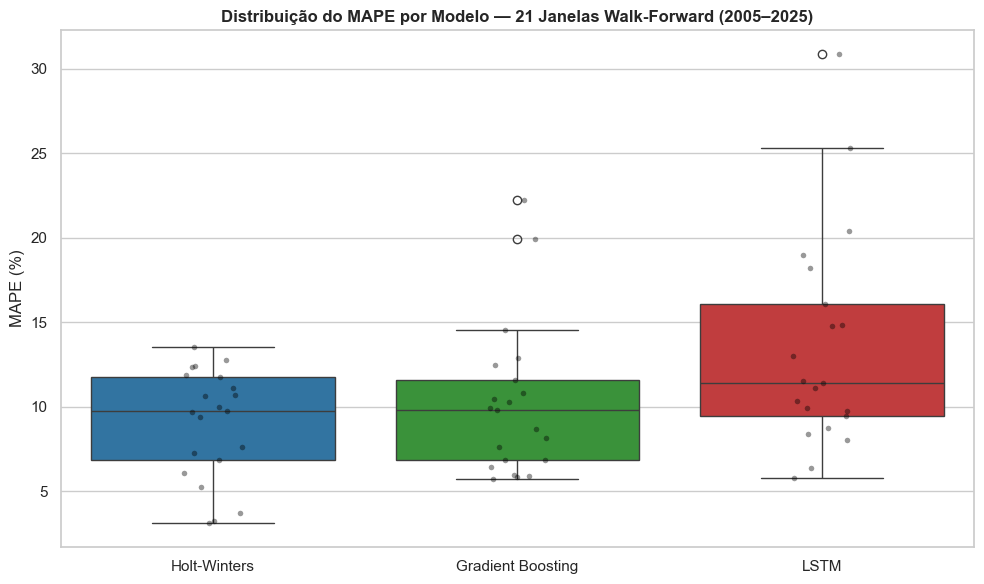

Figura salva: results/plots/02_boxplot_walkforward.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem = ["Holt-Winters", "Gradient Boosting", "LSTM"]
sns.boxplot(data=df_wf, x="modelo", y="mape", order=ordem, ax=ax,
            palette=["#1f77b4", "#2ca02c", "#d62728"])
sns.stripplot(data=df_wf, x="modelo", y="mape", order=ordem, ax=ax,
              color="black", alpha=0.4, size=4, jitter=True)

ax.set_title("Distribuição do MAPE por Modelo — 21 Janelas Walk-Forward (2005–2025)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("MAPE (%)")
plt.tight_layout()
plt.savefig("../results/plots/02_boxplot_walkforward.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/02_boxplot_walkforward.png")